# Model comparison — which LLM should answer the queries

Four candidate models, the same 15 questions, the same retrieved evidence.

**The context is retrieved once per question and given identically to every
model**, so the model is the only thing that varies. Letting each model trigger
its own retrieval would compare model-plus-retrieval and make any difference
impossible to attribute.

**No LLM judge is used.** The only models available are the models under test,
and a model scoring its own output carries a known self-preference bias.
Everything mechanical is measured automatically; everything requiring judgement
is scored by hand, blind.

In [1]:
import json, sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path.cwd()))
from measures import score_all  # noqa: E402

RESPONSES = Path("model_responses.json")
data = json.loads(RESPONSES.read_text())
scores = score_all()

SHORT = {m: m.split("/")[1].replace(":free", "") for m in scores.model.unique()}
scores["m"] = scores.model.map(SHORT)
ORDER = sorted(SHORT.values())

meta = data.get("metadata", {})
pd.Series({
    "responses collected": len(data["responses"]),
    "questions": meta.get("questions_answerable"),
    "runs per question": meta.get("runs_per_question"),
    "max attempts": meta.get("max_attempts"),
    "prompt version": meta.get("prompt_version"),
    "collected": meta.get("collected_at"),
}, name="value").to_frame()

,value
responses collected,151
questions,15
runs per question,2
max attempts,3
prompt version,2026-09-24.v5
collected,2026-10-04T08:29:35+00:00


## The questions

Fifteen, chosen to stress particular rules in the prompt rather than sampled at
random. Several exist because an earlier version of the system failed on them.

In [2]:
qs = pd.read_csv("model_questions.csv")
qs[["id", "question", "probes"]].set_index("id")

,question,probes
id,,
m01,What happened at the hospital?,scope summary; lead from [1]
m02,What did the white SUV do?,conflation across locations
m03,How many people were carrying backpacks at the...,counting
m04,Did an ambulance arrive at the hospital?,negative with irrelevant context
m05,Was anyone running at the school?,negative with irrelevant context
m06,Did anyone get out of a vehicle?,sparse evidence
m07,Was there a truck at the school?,unreliable detector labels
m08,Anything at the hospital on 5 March?,combined filter; same-occurrence rule
m09,What happened at the school between 2 and 3pm?,location and time filter


## Availability and latency

**Read availability with caution.** Partway through collection the OpenRouter
account hit its free-model daily limit, and those calls never reached a
provider. They have been removed from the data, but it means availability here
reflects a particular period rather than a stable property: the 550B recorded
zero successes on one day and thirty for thirty on the next.

What the data *does* support is the outlier. gemma-4-31b runs on a personal
Google key with no shared quota involved, and still failed repeatedly with
provider-side 502s and 504s.

In [3]:
rows = []
for m, g in scores.groupby("m"):
    answered = g[g.answered]
    rows.append({
        "answers": int(g.answered.sum()),
        "items attempted": len(g),
        "total calls": int(g.n_attempts.sum()),
        "calls per answer": round(g.n_attempts.sum() / max(g.answered.sum(), 1), 2),
        "median s": round(answered.seconds.median(), 1) if len(answered) else None,
        "slowest s": round(answered.seconds.max(), 1) if len(answered) else None,
    })
availability = pd.DataFrame(rows, index=sorted(scores.m.unique())).sort_values("calls per answer")
availability

,answers,items attempted,total calls,calls per answer,median s,slowest s
nemotron-3-ultra-550b-a55b,30,30,30,1.00,11.5,78.3
gemma-4-26b-a4b-it,30,30,34,1.13,3.8,7.3
nemotron-3-nano-omni-30b-a3b-reasoning,30,30,42,1.40,8.9,29.3
gemma-4-31b-it,13,61,167,12.85,16.4,40.4


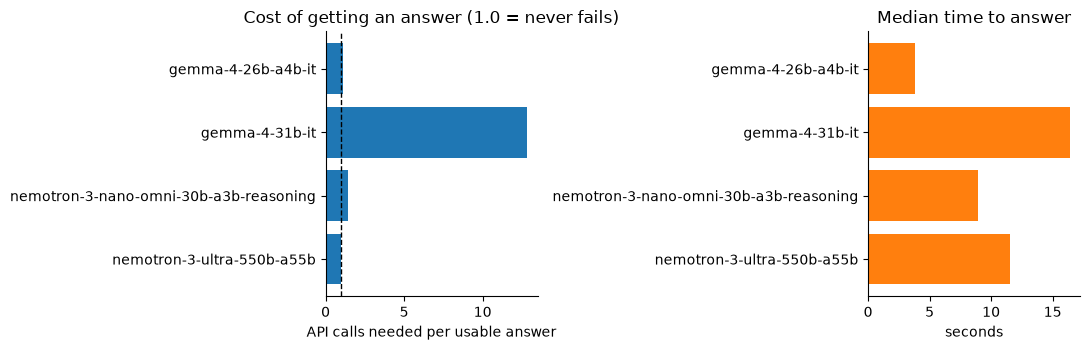

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
av = availability.sort_index()
ax1.barh(av.index, av["calls per answer"], color="C0")
ax1.set_xlabel("API calls needed per usable answer")
ax1.set_title("Cost of getting an answer (1.0 = never fails)")
ax1.axvline(1.0, color="black", linestyle="--", linewidth=1)
ax2.barh(av.index, av["median s"], color="C1")
ax2.set_xlabel("seconds")
ax2.set_title("Median time to answer")
for ax in (ax1, ax2):
    ax.invert_yaxis(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## Rule compliance

The prompt states rules, so following them can be counted rather than judged.
Each value is the share of that model's answers satisfying the rule.

- **cites / in range** — events cited as `[n]`, and the numbers actually exist
- **brackets clean** — square brackets used only for citations, never `[G341]`,
  which a frontend parsing citations would mis-link
- **no date** — no calendar date introduced that the question did not contain
- **no preamble** — does not open with "Based on the retrieved events…"
- **grounded** — no location or camera named that was absent from the context

In [5]:
RULES = ["cites_anything", "cites_in_range", "brackets_clean", "no_date",
         "no_preamble", "is_grounded"]
answered = scores[scores.answered]
compliance = answered.groupby("m")[RULES].mean().round(3)
compliance["n answers"] = answered.groupby("m").size()
compliance

,cites_anything,cites_in_range,brackets_clean,no_date,no_preamble,is_grounded,n answers
m,,,,,,,
gemma-4-26b-a4b-it,0.933333,0.933333,1.0,1.0,1.0,1.0,30
gemma-4-31b-it,0.692308,0.692308,1.0,1.0,1.0,1.0,13
nemotron-3-nano-omni-30b-a3b-reasoning,0.833333,0.833333,1.0,1.0,1.0,1.0,30
nemotron-3-ultra-550b-a55b,0.966667,0.966667,1.0,0.866667,1.0,1.0,30


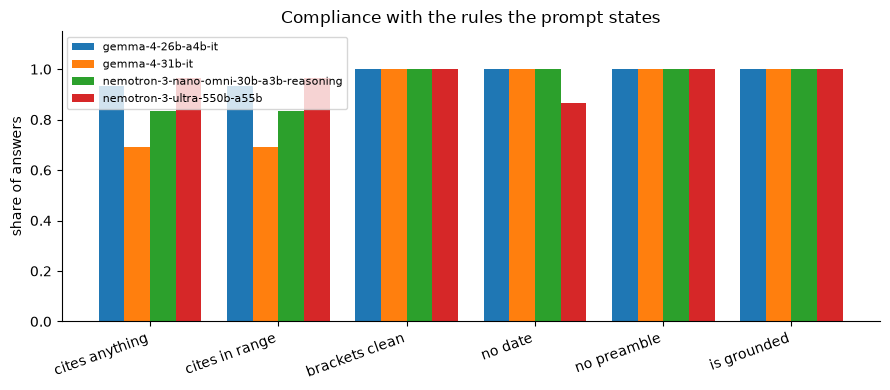

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
width = 0.8 / len(ORDER)
for i, m in enumerate(ORDER):
    vals = [compliance.loc[m, r] for r in RULES]
    ax.bar([x + i * width for x in range(len(RULES))], vals, width, label=m)
ax.set_xticks([x + 0.4 - width / 2 for x in range(len(RULES))])
ax.set_xticklabels([r.replace("_", " ") for r in RULES], rotation=20, ha="right")
ax.set_ylabel("share of answers")
ax.set_ylim(0, 1.15)
ax.set_title("Compliance with the rules the prompt states")
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

### Concise refusals

Three questions ask about things absent from every caption. The prompt says that
when the answer is no, give one sentence and stop — a long answer to a question
with nothing to report is room for mistakes.

In [7]:
neg = answered[answered.is_negative]
refusals = neg.groupby("m").agg(
    answers=("concise_refusal", "size"),
    one_sentence=("concise_refusal", "sum"),
    median_sentences=("sentences", "median"),
)
refusals

,answers,one_sentence,median_sentences
m,,,
gemma-4-26b-a4b-it,6,2,2.0
gemma-4-31b-it,3,2,1.0
nemotron-3-nano-omni-30b-a3b-reasoning,6,5,1.0
nemotron-3-ultra-550b-a55b,6,0,2.0


## Style and stability

- **extractiveness** — share of the answer's content words that appear in the
  supplied captions. Higher means it stays closer to the evidence.
- **relevancy** — embedding similarity of the answer to the question and to the
  context, using the same bge model the index is built with.
- **consistency** — similarity between the two runs of the same question at
  temperature 0. A model that answers differently each time is harder to
  evaluate and harder to trust.

In [8]:
style = answered.groupby("m").agg(
    median_words=("words", "median"),
    median_sentences=("sentences", "median"),
    extractiveness=("extractiveness", "mean"),
    relevancy_question=("relevancy_to_question", "mean"),
    relevancy_context=("relevancy_to_context", "mean"),
    consistency=("consistency", "mean"),
).round(3)
style

,median_words,median_sentences,extractiveness,relevancy_question,relevancy_context,consistency
m,,,,,,
gemma-4-26b-a4b-it,61.0,4.0,0.731,0.755,0.776,1.000
gemma-4-31b-it,29.0,2.0,0.677,0.716,0.735,0.909
nemotron-3-nano-omni-30b-a3b-reasoning,17.5,2.0,0.597,0.705,0.715,0.835
nemotron-3-ultra-550b-a55b,64.5,3.0,0.582,0.680,0.784,0.924


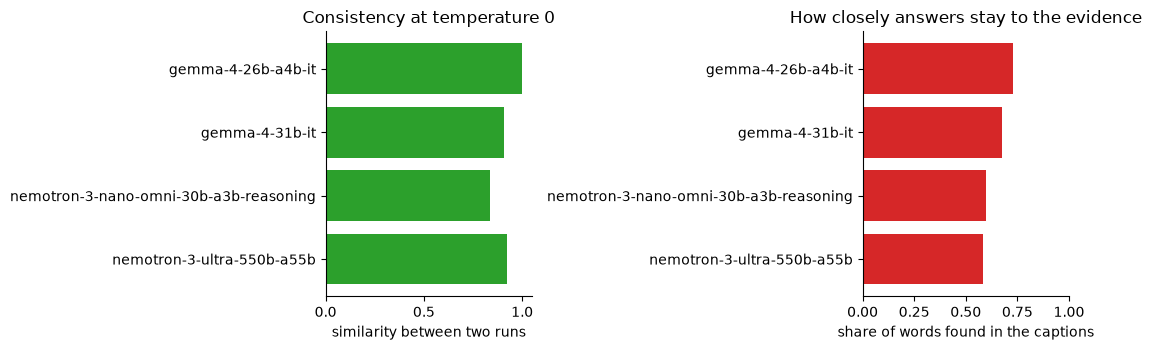

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
st = style.sort_index()
ax1.barh(st.index, st.consistency, color="C2")
ax1.set_xlim(0, 1.05); ax1.set_xlabel("similarity between two runs")
ax1.set_title("Consistency at temperature 0")
ax2.barh(st.index, st.extractiveness, color="C3")
ax2.set_xlim(0, 1.0); ax2.set_xlabel("share of words found in the captions")
ax2.set_title("How closely answers stay to the evidence")
for ax in (ax1, ax2):
    ax.invert_yaxis(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## Quality scores — LLM as judge

Fifty-two answers scored on correctness, faithfulness and usefulness (1–5),
assigned from the question, the supplied context and the answer alone.

**The judge is Claude, which is not one of the four models under test.** That
removes the self-preference bias that ruled out using a candidate model as its
own examiner — a model scoring its own output cannot be relied on.

Every score carries a written justification in `judge_scores.csv`, and the full
set was reviewed and accepted by the project author before being used.

- **correctness** — does it answer the question, given the evidence supplied
- **faithfulness** — is every claim traceable to a supplied event
- **usefulness** — would it help someone reviewing footage


In [10]:
judge = pd.read_csv("judge_scores.csv")
DIMS = ["correctness", "faithfulness", "usefulness"]
judge["m"] = judge.model.map(SHORT)

summary = judge.groupby("m")[DIMS].mean().round(2)
summary["mean"] = summary.mean(axis=1).round(2)
summary["n scored"] = judge.groupby("m").size()
print(f"{len(judge)} answers scored")
summary.sort_values("mean", ascending=False)


52 answers scored


,correctness,faithfulness,usefulness,mean,n scored
m,,,,,
nemotron-3-ultra-550b-a55b,4.93,4.93,4.87,4.91,15
gemma-4-26b-a4b-it,4.27,4.40,4.20,4.29,15
gemma-4-31b-it,3.71,4.14,3.57,3.81,7
nemotron-3-nano-omni-30b-a3b-reasoning,3.67,4.47,2.93,3.69,15


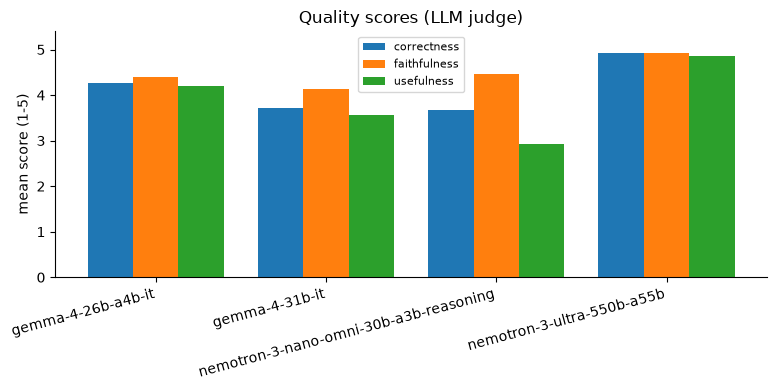

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
width = 0.8 / len(DIMS)
present = [m for m in ORDER if m in set(judge.m)]
for i, dim in enumerate(DIMS):
    vals = [judge[judge.m == m][dim].mean() for m in present]
    ax.bar([x + i * width for x in range(len(present))], vals, width, label=dim)
ax.set_xticks([x + 0.4 - width / 2 for x in range(len(present))])
ax.set_xticklabels(present, rotation=15, ha="right")
ax.set_ylim(0, 5.4); ax.set_ylabel("mean score (1-5)")
ax.set_title("Quality scores (LLM judge)")
ax.legend(fontsize=8); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()


## The answers themselves

Numbers compress away the thing you actually care about. These are complete
answers to the same question, from the same evidence, side by side.

In [12]:
def show(qid):
    q = data["questions"][qid]
    print(f"QUESTION  {qid}: {q['question']}")
    print(f"PROBES    {qs.set_index('id').loc[qid, 'probes']}")
    print(f"FILTER    {q['filter']}   ({q['n_sources']} events supplied)\n")
    for m in ORDER:
        hit = [r for r in data["responses"]
               if SHORT[r["model"]] == m and r["question_id"] == qid
               and r["run"] == "1" and r.get("answer")]
        text = " ".join(hit[0]["answer"].split()) if hit else "(no answer produced)"
        print(f"--- {m}")
        for i in range(0, len(text), 110):
            print(f"      {text[i:i+110]}")
    print("=" * 100)

show("m04")   # negative question with irrelevant context supplied

QUESTION  m04: Did an ambulance arrive at the hospital?
PROBES    negative with irrelevant context
FILTER    location hospital   (5 events supplied)

--- gemma-4-26b-a4b-it
      No, an ambulance does not appear in any of the hospital footage.
--- gemma-4-31b-it
      No ambulance appears in any of the hospital footage.
--- nemotron-3-nano-omni-30b-a3b-reasoning
      No ambulance appears in any of the hospital footage.
--- nemotron-3-ultra-550b-a55b
      No ambulance appears in any of the hospital footage. The closest event [1] shows only a dark sedan parking nea
      r the entrance.


In [13]:
show("m02")   # similar vehicles in different locations - the conflation trap

QUESTION  m02: What did the white SUV do?
PROBES    conflation across locations
FILTER    none   (5 events supplied)

--- gemma-4-26b-a4b-it
      The white SUV's actions vary across different sightings: * At the bus location, it was parked near a grassy ar
      ea before driving forward and exiting the frame to the right [1], or it moved from the bottom-left toward the 
      bottom-right along a paved road [2]. * At the school location, it entered from the right and moved left [3], d
      rove from the left to the right past an orange utility vehicle [4], or moved forward from a parked position on
       the left, passing a parked white SUV and a dark sedan [5].
--- gemma-4-31b-it
      A white SUV parked near a grassy area moved forward and drove past the camera at 16:51 [1]. Other white SUVs w
      ere seen: * At 13:17, one moved from the bottom-left to the bottom-right at the bus location [2]. * At 16:51, 
      one drove from right to left at the school location [3]. * At 13:2

In [14]:
show("m15")   # cross-camera identity, which the system does not track

QUESTION  m15: Did the same person appear on more than one camera?
PROBES    multi-camera identity
FILTER    none   (3 events supplied)

--- gemma-4-26b-a4b-it
      Yes, the person in the brown jacket and dark backpack appears on camera G505 at 11:04 [1] and is also seen at 
      the same location on camera G505 at 11:03 [2].
--- gemma-4-31b-it
      (no answer produced)
--- nemotron-3-nano-omni-30b-a3b-reasoning
      No, the footage shows different individuals on each camera.
--- nemotron-3-ultra-550b-a55b
      No. The three events show people at two different locations (bus and school) on different days, and the only t
      wo events from the same location [1] and [2] come from the same camera (G505). There is no sighting of a match
      ing person on a different camera.


## Decision matrix

Availability is shown but **not treated as a ranking criterion**, for the reason
given above: it moved too much between days to be a stable property of a model.
The exception is gemma-4-31b, whose failures are provider-side and reproducible.

In [15]:
matrix = pd.DataFrame(index=sorted(scores.m.unique()))
matrix["calls per answer"] = availability["calls per answer"]
matrix["median s"] = availability["median s"]
matrix["rule compliance"] = compliance[RULES].mean(axis=1).round(3)
matrix["concise refusals"] = (refusals.one_sentence / refusals.answers).round(2)
matrix["extractiveness"] = style.extractiveness
matrix["consistency"] = style.consistency
matrix["answers collected"] = compliance["n answers"]
if True:
    matrix["judge mean"] = judge.groupby("m")[DIMS].mean().mean(axis=1).round(2)
matrix.sort_values("rule compliance", ascending=False)

,calls per answer,median s,rule compliance,concise refusals,extractiveness,consistency,answers collected,judge mean
gemma-4-26b-a4b-it,1.13,3.8,0.978,0.33,0.731,1.000,30,4.29
nemotron-3-ultra-550b-a55b,1.00,11.5,0.967,0.0,0.582,0.924,30,4.91
nemotron-3-nano-omni-30b-a3b-reasoning,1.40,8.9,0.944,0.83,0.597,0.835,30,3.69
gemma-4-31b-it,12.85,16.4,0.897,0.67,0.677,0.909,13,3.81


## Limitations

**Fifteen questions, four models.** Enough to establish that one model cites and
another does not. Not enough to support a claim like "model A is 12% better".

**Unequal samples.** gemma-4-31b contributes 7 scored answers against 15 for each
of the others, because it could not produce the rest.

**Availability is confounded.** An account-level quota limit was mixed in with
genuine provider failures during collection. The quota-caused records were
removed, but the remaining figures still reflect particular days rather than a
stable property of a model.

**The automatic measures check discipline, not correctness.** A fluent,
well-cited, perfectly grounded answer can still miss the point of the question —
which is exactly what the quality scores are for.

**Free-tier models only.** A paid model was not evaluated and could change the
recommendation, particularly on latency and reliability.
